Import libraries

In [1]:
import numpy as np
import xarray as xr
import cf_xarray
from xgcm import Grid, generate_grid_ds
import gsw_xarray as gsw

import neutralocean
import neutralocean.grid.rectilinear
import neutralocean.ntp

from xgcm import Grid
import gsw_xarray as gsw

import matplotlib.pyplot as plt

import jax
from jax import numpy as jnp
import optax
import matplotlib.pyplot as plt

In [2]:
import neutral_density as nd

In [3]:
from importlib import reload

In [217]:
reload(nd)

<module 'neutral_density' from '/home/romain/Documents/work/2025-Jaxathon/neutral-density/src/neutral_density/__init__.py'>

In [218]:
ds = xr.open_dataset("dataset.nc")

In [219]:
ds = ds.isel(x_c=[-30], x_f=[-30])

## Create geometrical variables

* scale factors
* mask

In [220]:
e1u = jnp.array(ds.e1tu.broadcast_like(ds.t_an).transpose("x_c", "y_c", "z_c"))
e2v = jnp.array(ds.e2.broadcast_like(ds.t_an).transpose("x_c", "y_c", "z_c"))
e3w = jnp.array(ds.e3w.broadcast_like(ds.z_f+ds.x_c+ds.y_c).transpose("x_c", "y_c", "z_f"))

In [221]:
e123t = e1u * e2v * e3w
mask_water = 1 # only when we can compute derivatives ## TODO
tot_vol = (e123t*mask_water).sum()
weight_per_point = e123t / tot_vol

In [222]:
mask_T = jnp.isfinite(jnp.array(ds.cf["sea_water_temperature"])).astype(jnp.int32)

/tmp/ipykernel_721485/2949225597.py:1: UserWarning: Variables {'crs', 'time'} not found in object but are referred to in the CF attributes.
  mask_T = jnp.isfinite(jnp.array(ds.cf["sea_water_temperature"])).astype(jnp.int32)


In [223]:
gradient_of_the_mask = nd.gradient_centered(mask_T, 0*mask_T+1, 0*mask_T+1, 0*mask_T+1)

In [224]:
mask_gradient = (gradient_of_the_mask==0) & (jnp.array([mask_T, mask_T, mask_T]))
mask_gradient = mask_gradient.at[2,:,:,0].set(0) # surface
mask_gradient = mask_gradient.at[2,:,:,-1].set(0) # last point
# Attention vertical component

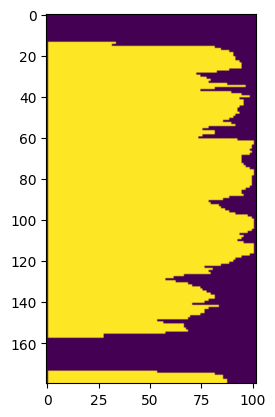

In [225]:
plt.imshow(mask_gradient[2][0])

In [226]:
mask_gradient.shape

(3, 1, 180, 102)

In [227]:
ds = ds.fillna(0.)

## Computing reference density gradient $\vec{A}$

$$
\vec{A'} = - \alpha \vec{\nabla} \Theta + \beta \vec{\nabla} S_A
$$

$$
\rho = \rho_0 (-\alpha (\Theta - \Theta_0))
$$


We use centred finite differences so everything is at the T points

In [228]:
dCT = nd.gradient_centered(jnp.array(ds.cf["sea_water_conservative_temperature"]), e1u, e2v, e3w)
dSA = nd.gradient_centered(jnp.array(ds.cf["sea_water_absolute_salinity"]), e1u, e2v, e3w)

In [229]:
# lin EOS in temperature only
# alpha = 2e-4 ## approx mean value of alpha
# beta = 0

In [230]:
alpha = 2e-4
beta = 0

In [231]:
A = (-alpha * dCT + beta * dSA) * mask_gradient

## Solve the problem

In [232]:
gamma0 = jax.numpy.array(
    (1-(ds.cf["sea_water_conservative_temperature"].mean(
        ["x_c", "y_c"]
    ).broadcast_like(ds.cf["sea_water_conservative_temperature"]) - 10)
    * alpha) * 1026
)

In [233]:
gamma0.shape

(1, 180, 102)

In [234]:
nd.loss(
    gamma0, A, e1u, e2v, e3w, weight_per_point, mask_gradient,
    normalization=jnp.array([1e5, 1e5, 1])[:, jnp.newaxis, jnp.newaxis, jnp.newaxis]
)

Array(8.522918e-15, dtype=float32)

In [235]:
nd.loss_components(
    gamma0, A, e1u, e2v, e3w, weight_per_point, mask_gradient,
    normalization=jnp.array([1e5, 1e5, 1])[:, jnp.newaxis, jnp.newaxis, jnp.newaxis]
)

Array([8.522918e-15, 0.000000e+00, 0.000000e+00], dtype=float32)

In the theoretical case of a linear EOS, we know that there exists a solution, and what it is. Normalizing the loss function should only play a role in the speed of minimization, and/or in the accuracy (due to numerical errors).

We can thus start the minimization problem

### Optimization of $\gamma$

In [322]:
floss = lambda gamma: nd.loss(gamma, A, e1u, e2v, e3w, weight_per_point, mask_gradient,
    normalization=jnp.array([1, 1, 1e15])[:, jnp.newaxis, jnp.newaxis, jnp.newaxis])

In [323]:
grad_loss = jax.grad(floss)

def train(params, learning_rate=0.01, num_steps=1000):
    """Train using gradient descent optimization"""
    # Define optimizer
    optimizer = optax.adam(learning_rate)
    opt_state = optimizer.init(params)
    
    losses = []
    
    for step in range(num_steps):
        # Compute loss and gradients
        loss = floss(params)
        #grads = jnp.nan_to_num(grad_loss(params))
        grads = grad_loss(params)
        
        losses.append(loss)
        
        # Apply updates
        updates, opt_state = optimizer.update(grads, opt_state)
        params = optax.apply_updates(params, updates)
        
        # Print progress every 100 steps
        if step % 100 == 0:
            print(f"Step {step}, Loss: {loss}")
            plt.imshow(params[0,:,:].T)
            plt.show()
    
    return params, losses

In [324]:
initial_gamma = gamma0

In [325]:
floss(initial_gamma)

Array(852291.75, dtype=float32)

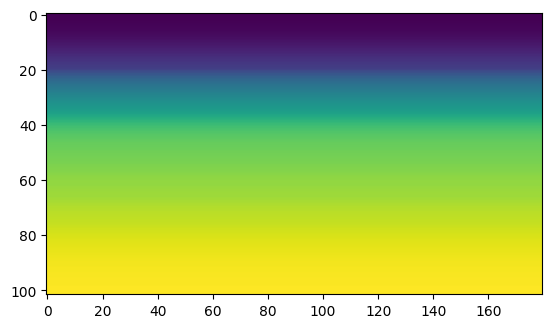

In [326]:
plt.imshow(initial_gamma[0,:,:].T)

In [327]:
g = grad_loss(initial_gamma)

In [328]:
C = nd.loss_at_each_point(initial_gamma, A, e1u, e2v, e3w, weight_per_point, mask_gradient,
    normalization=jnp.array([1, 1, 1e5])[:, jnp.newaxis, jnp.newaxis, jnp.newaxis])

In [329]:
mask_gradient.shape

(3, 1, 180, 102)

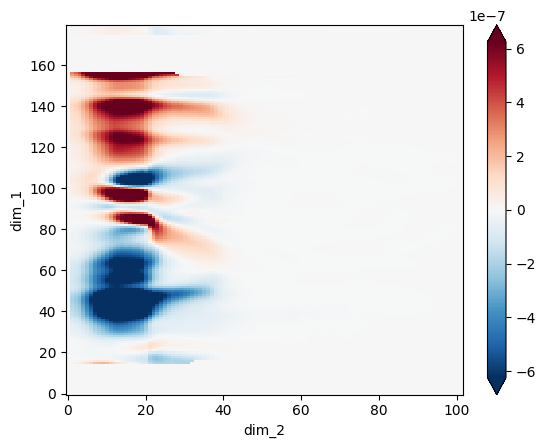

In [330]:
xr.DataArray((C*mask_gradient)[0]).plot(robust=True)

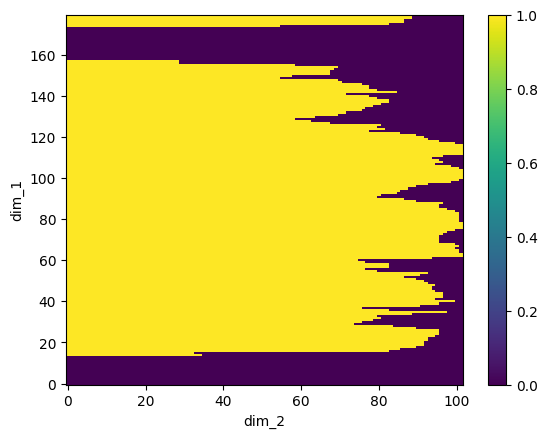

In [331]:
xr.DataArray((mask_gradient)[0]).plot(robust=True)

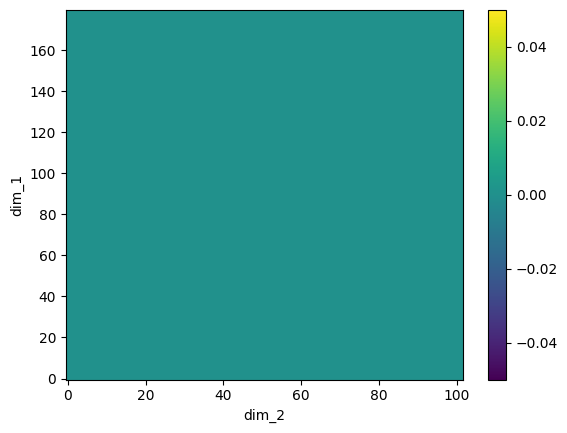

In [332]:
xr.DataArray(C[1]).plot(robust=True)

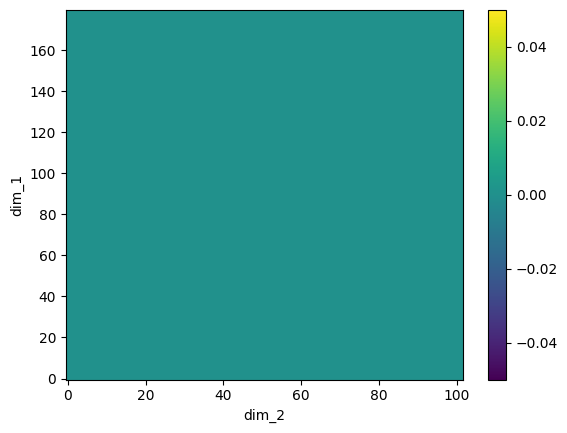

In [333]:
xr.DataArray(C[2]).plot(robust=True)

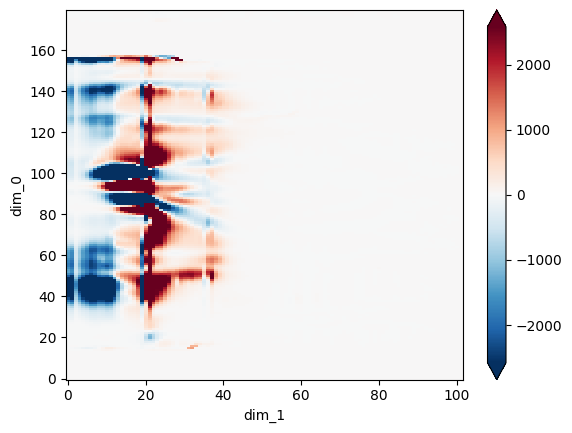

In [334]:
xr.DataArray(g[0]).plot(robust=True)

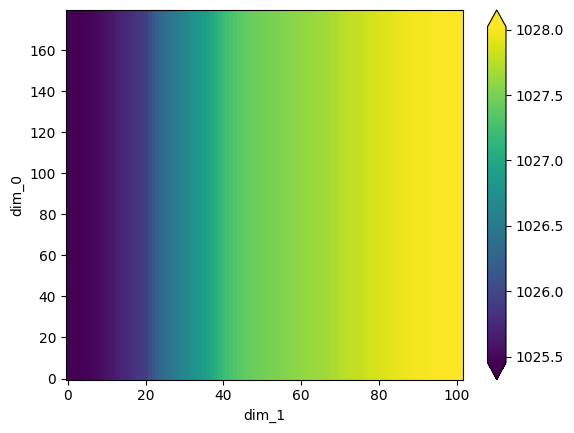

In [335]:
xr.DataArray(initial_gamma[0]).plot(robust=True)

Step 0, Loss: 852291.75


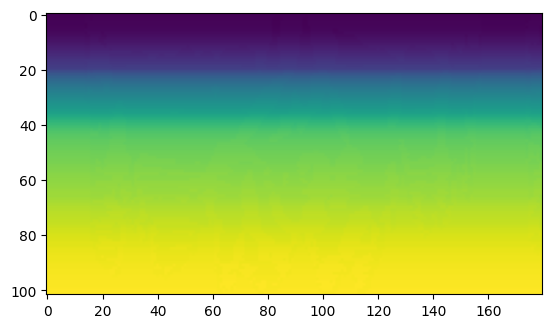

Step 100, Loss: 22236.04296875


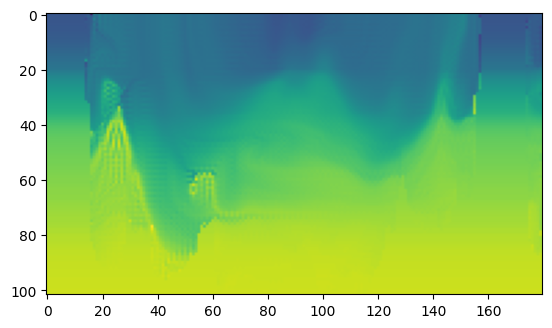

Step 200, Loss: 4469.6123046875


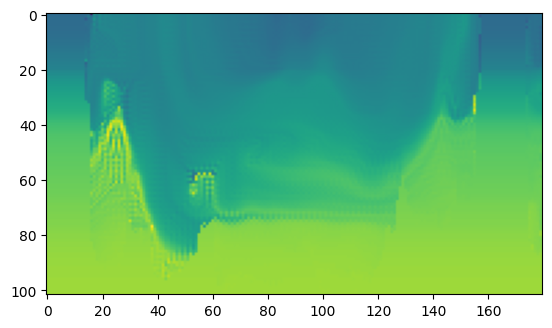

Step 300, Loss: 917.9105224609375


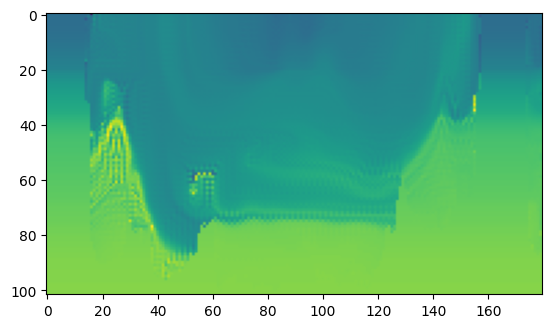

Step 400, Loss: 298.6417236328125


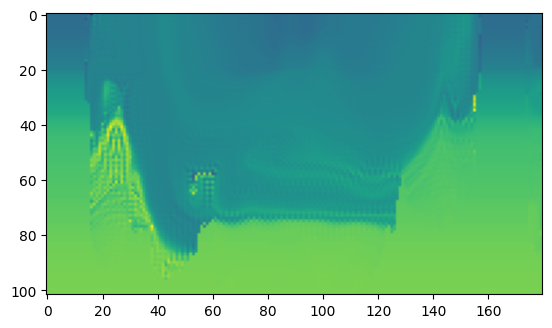

Step 500, Loss: 176.65997314453125


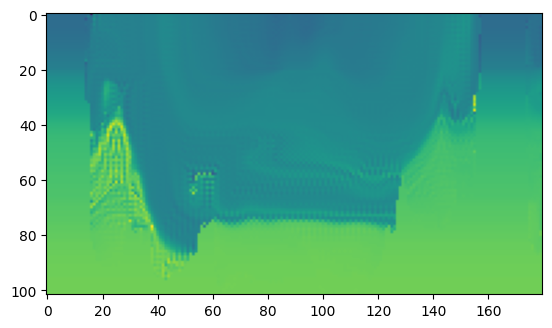

Step 600, Loss: 119.55642700195312


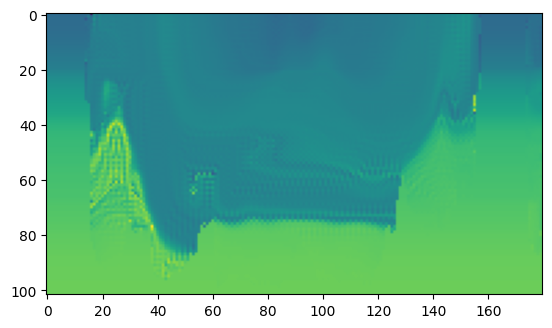

Step 700, Loss: 81.87147521972656


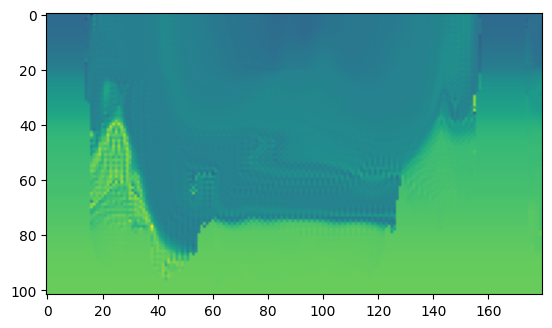

Step 800, Loss: 94.5174560546875


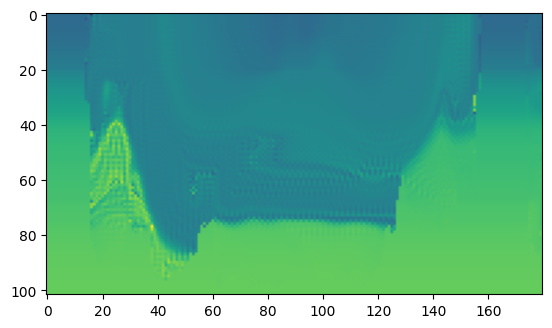

Step 900, Loss: 90.12950134277344


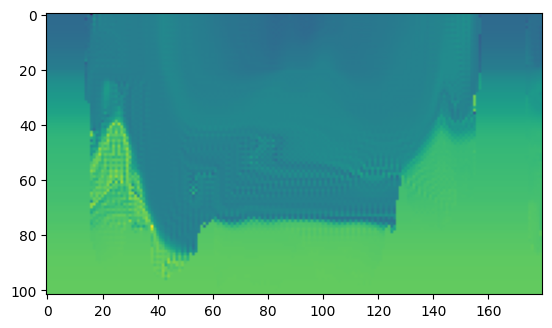

Optimization complete!
Initial loss: 852291.75
Final loss: 94.27720642089844


In [337]:
   
# Run optimization
optimal_gamma, loss_history = train(
    initial_gamma, 
    learning_rate=.01, 
    num_steps=1000
)

print("Optimization complete!")
print(f"Initial loss: {floss(initial_gamma)}")
print(f"Final loss: {floss(optimal_gamma)}")

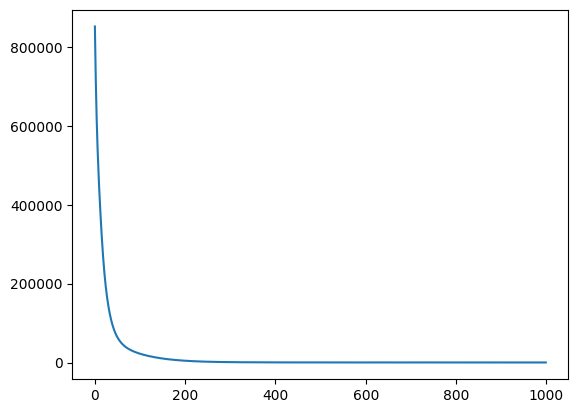

In [338]:
plt.plot(loss_history)

In [97]:
plt.imshow(ds.CT[0].T)

np.float32(0.0)

In [150]:
gamma1 = jax.numpy.array(
    (1-(ds.cf["sea_water_conservative_temperature"] - 10)
    * alpha) * 1026
)

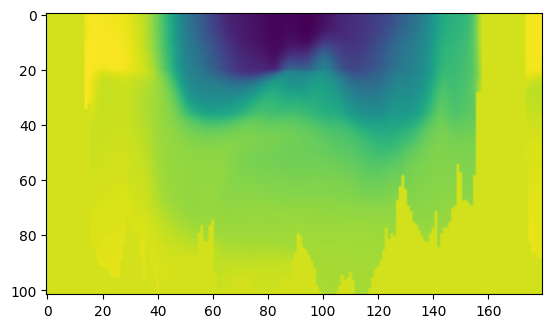

In [151]:
plt.imshow(gamma1[0].T)